## **Loan Approval Prediction Using Machine Learning**

Bank receives many loan applications.manually evaluating every application can be time consuming.
A machine learning system can learn patterns from previous loan applications and predict whether a new applicant is likely to be approved

Used data link:
https://drive.google.com/file/d/1LIvIdqdHDFEGnfzIgEh4L6GFirzsE3US/view

Dataset contains:
 598 rows x 13 columns

**Project Overview**:

This project uses the provided dataset to predict whether a loan application will be approved(Y) or rejected(N).

Complete Work Flow:

Dataset----> Data understanding----> Data Cleaning----> EDA---->Visualization---> Preprocessing--> Feature encoding---> Train/test split--->Model Training---> comparison----> Model Evaluation--->Prediction

**Importing Libraries and Dataset**:


*  Pandas     - To load the dataframe
*  Matplotlib - To visualize the data features
*  seaborn    - To see the correlation between features using heatmap















Data Set

In [37]:
# 1.Data Set
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/LoanApprovalPrediction.csv")
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,LP002978,Female,No,0.0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
594,LP002979,Male,Yes,3.0,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
595,LP002983,Male,Yes,1.0,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
596,LP002984,Male,Yes,2.0,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


# **Data preprocessing and Visualization**

In [38]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [39]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
593,LP002978,Female,No,0.0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
594,LP002979,Male,Yes,3.0,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
595,LP002983,Male,Yes,1.0,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
596,LP002984,Male,Yes,2.0,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
597,LP002990,Female,No,0.0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [40]:
# Check dimensions:
df.shape



(598, 13)

**BASIC DATASET INFORMATION**

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            598 non-null    object 
 1   Gender             598 non-null    object 
 2   Married            598 non-null    object 
 3   Dependents         586 non-null    float64
 4   Education          598 non-null    object 
 5   Self_Employed      598 non-null    object 
 6   ApplicantIncome    598 non-null    int64  
 7   CoapplicantIncome  598 non-null    float64
 8   LoanAmount         577 non-null    float64
 9   Loan_Amount_Term   584 non-null    float64
 10  Credit_History     549 non-null    float64
 11  Property_Area      598 non-null    object 
 12  Loan_Status        598 non-null    object 
dtypes: float64(5), int64(1), object(7)
memory usage: 60.9+ KB


**Check Column Names**

In [42]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

**Statistical Summary**

In [43]:
df.describe()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,586.000000,598.000000,598.000000,577.000000,584.000000,549.000000
mean,0.755973,5292.252508,1631.499866,144.968804,341.917808,0.843352
std,1.007751,5807.265364,2953.315785,82.704182,65.205994,0.363800
min,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000
25%,0.000000,2877.500000,0.000000,100.000000,360.000000,1.000000
50%,0.000000,3806.000000,1211.500000,127.000000,360.000000,1.000000
75%,1.750000,5746.000000,2324.000000,167.000000,360.000000,1.000000
max,3.000000,81000.000000,41667.000000,650.000000,480.000000,1.000000


In [44]:
# for categorical variable:
df.describe(include="object")

,Loan_ID,Gender,Married,Education,Self_Employed,Property_Area,Loan_Status
count,598,598,598,598,598,598,598
unique,598,2,2,2,2,3,2
top,LP002990,Male,Yes,Graduate,No,Semiurban,Y
freq,1,487,388,465,488,225,411


In [45]:
# checking missing values:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,12
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,21
Loan_Amount_Term,14


Dataset contain missing values in:
Dependents,LoanAmount,Loan_Amount_Term,Credit_History

In [46]:
# check duplicate records
df.duplicated().sum()

np.int64(0)

In [47]:
df.drop_duplicates()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,LP002978,Female,No,0.0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
594,LP002979,Male,Yes,3.0,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
595,LP002983,Male,Yes,1.0,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
596,LP002984,Male,Yes,2.0,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


Get number of columns of object datatype

In [48]:
obj=(df.dtypes=='objecct')
print("Categorical variables:",len(list(obj[obj].index)))

Categorical variables: 0


VISUALIZATION

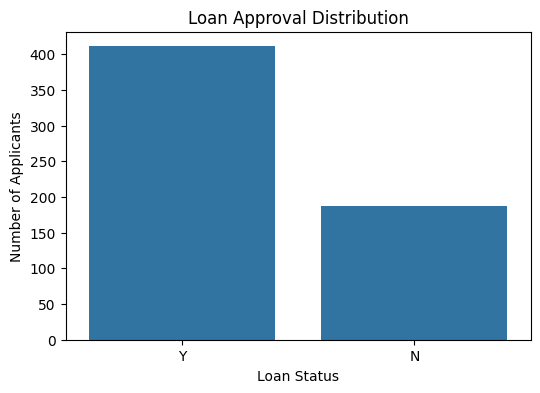

In [49]:
# Target variable visualization
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Loan_Status")

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")

plt.show()
# this shows how many applicant where approved, rejected-this tells whether the target classes are balanced

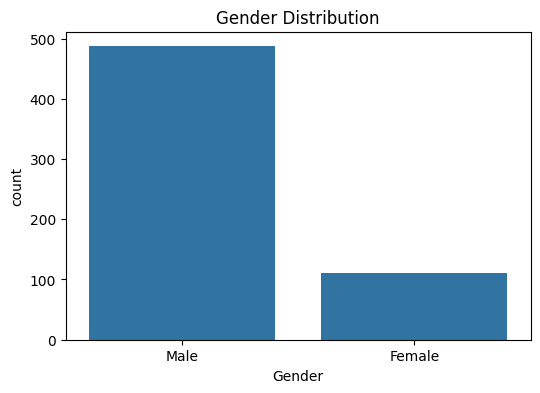

In [17]:
# Gender distribution
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Gender")

plt.title("Gender Distribution")

plt.show()

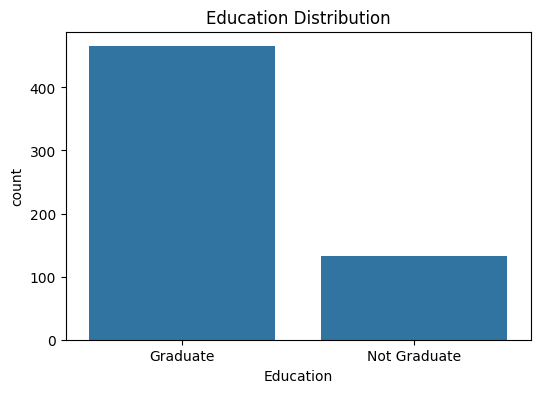

In [18]:
# Education distribution
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Education")

plt.title("Education Distribution")

plt.show()

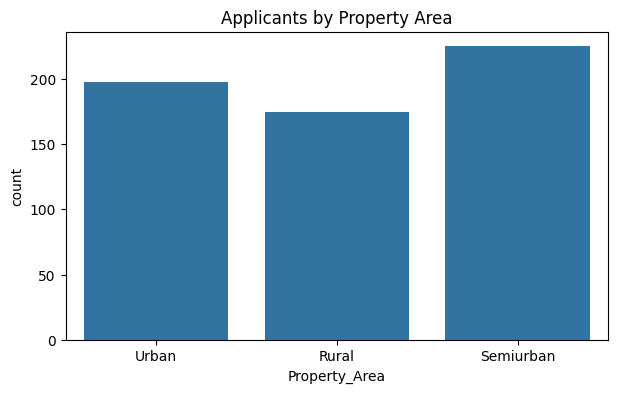

In [19]:
# Propert Area distribution
plt.figure(figsize=(7,4))

sns.countplot(data=df, x="Property_Area")

plt.title("Applicants by Property Area")

plt.show()

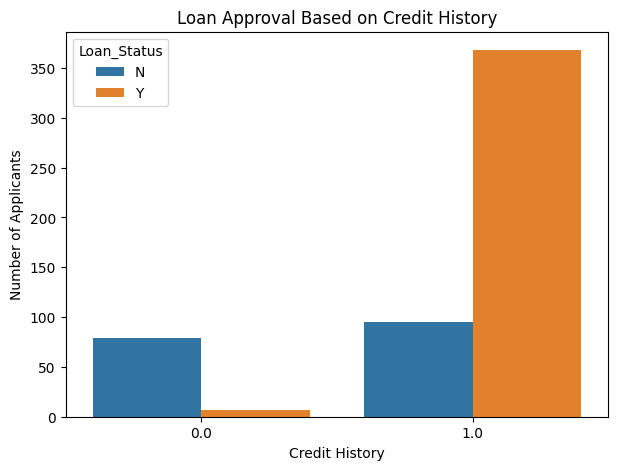

In [20]:
# Loan status based on credit history
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Credit_History",
    hue="Loan_Status"
)

plt.title("Loan Approval Based on Credit History")

plt.xlabel("Credit History")
plt.ylabel("Number of Applicants")

plt.show()
# most important visualization. Credit history has a strong relationship with loan approval.
# Applicant with good credit history are generally much more likely to receive loan approval.
# this is why credit history becomes important feature

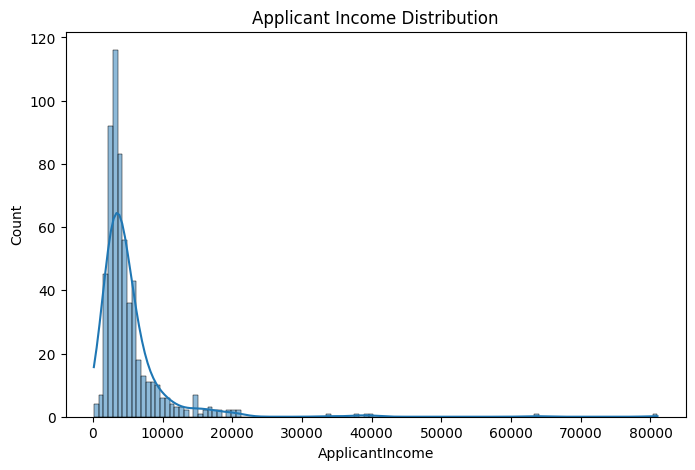

In [21]:
# Applicant income distribution
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="ApplicantIncome",
    kde=True
)

plt.title("Applicant Income Distribution")

plt.show()

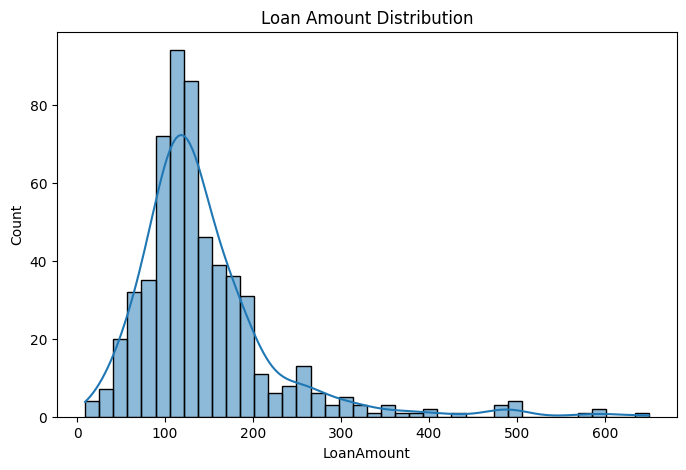

In [22]:
# Loan Amount distribution
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="LoanAmount",
    kde=True
)

plt.title("Loan Amount Distribution")

plt.show()

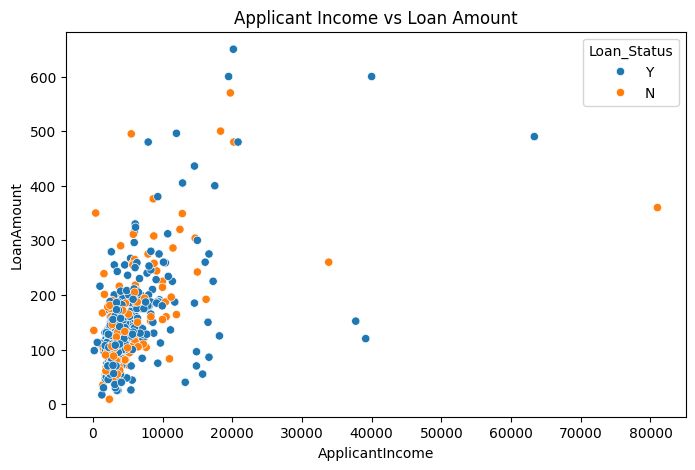

In [23]:
# Applicant income vs Loan amount
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="ApplicantIncome",
    y="LoanAmount",
    hue="Loan_Status"
)

plt.title("Applicant Income vs Loan Amount")

plt.show()
# helps to explain whether applicant with higher income tend to request larger loans and whether approval differs between applicants

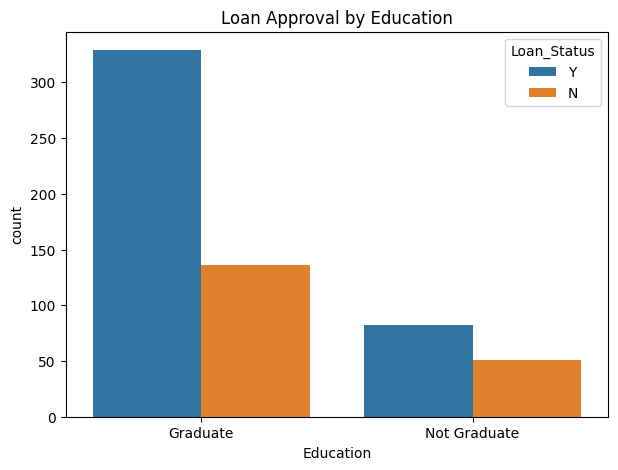

In [24]:
# Loan approval by education
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Education",
    hue="Loan_Status"
)

plt.title("Loan Approval by Education")

plt.show()

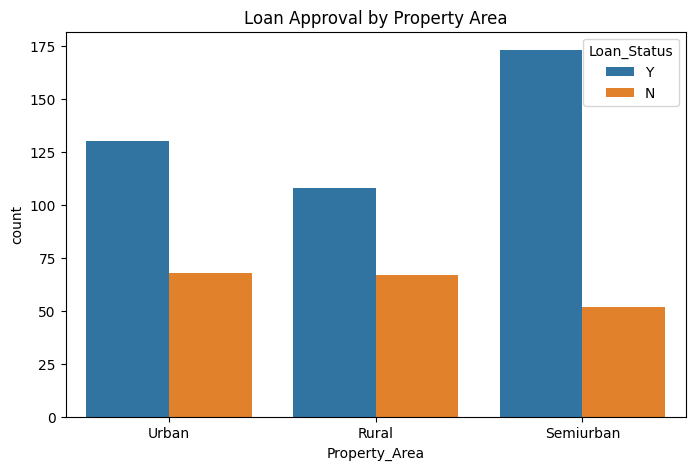

In [25]:
# Loan approval by property area
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Property_Area",
    hue="Loan_Status"
)

plt.title("Loan Approval by Property Area")

plt.show()

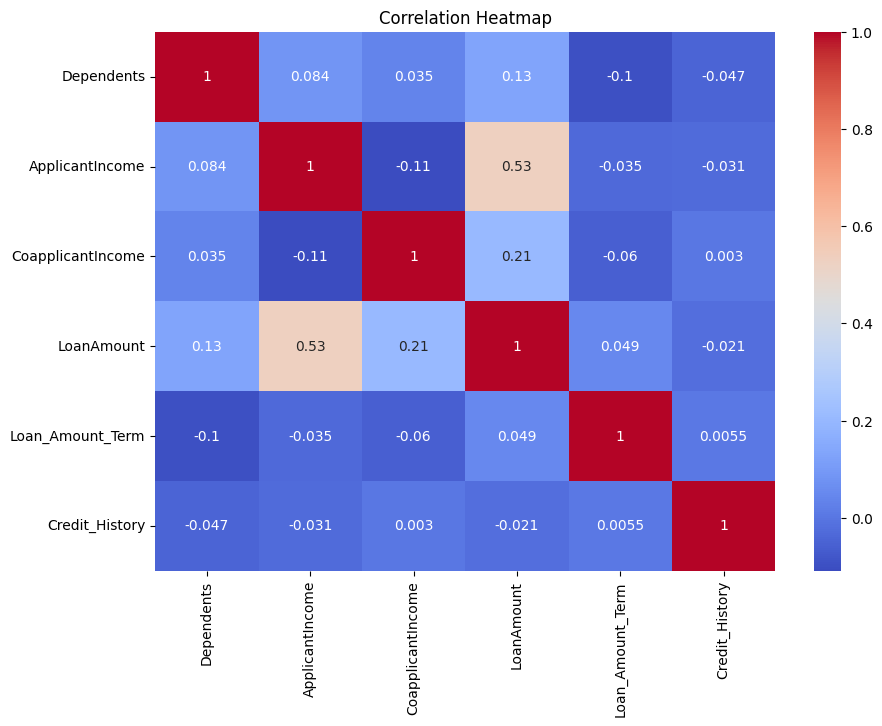

In [35]:
# Correlation heat map
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()
# help us understand relation between numerical variables.

**Splitting Dataset**

In [51]:
from sklearn.model_selection import train_test_split

x = df.drop(["Loan_ID", "Loan_Status"], axis=1)

y = df["Loan_Status"].map({
    "Y": 1,
    "N": 0
})
x.shape,y.shape

x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.4,
                                                    random_state=1)
x_train.shape, x_test.shape, y_train.shape, y_test.shape
# x independent variable Y- target variable

((358, 11), (240, 11), (358,), (240,))

In [52]:
# Identify categorical and numerical columns
categorical_features = X.select_dtypes(
    include=["object"]
).columns

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
Index(['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area'], dtype='object')

Numerical Features:
Index(['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')


**PREPROCESSING**

Numerical variables----missing value--- median

scaling---standardscaler

Categorical variables----mode---most frequent
encoding---onehot encoding

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [55]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [57]:
# combine them
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [ ]:

# why use pipeline:
# the pipeline ensures that preprocessing is applied correctley to training and testing data
# and helps prevent data leakage

Train Test split

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
# 80% training 20% testing
# startify=y maintains approximately the same proportion of loans approved/rejected in both sets.

In [60]:
# LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

Accuracy: 0.8083333333333333


In [61]:
# Descision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
dt_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        ))
    ]
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred_dt))

Accuracy: 0.8


In [63]:
# RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ))
    ]
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Accuracy: 0.8083333333333333


In [64]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(
            random_state=42
        ))
    ]
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred_gb))

Accuracy: 0.8166666666666667


In [65]:
# compare All models
from sklearn.metrics import accuracy_score
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.808333
1,Decision Tree,0.800000
2,Random Forest,0.808333
3,Gradient Boosting,0.816667


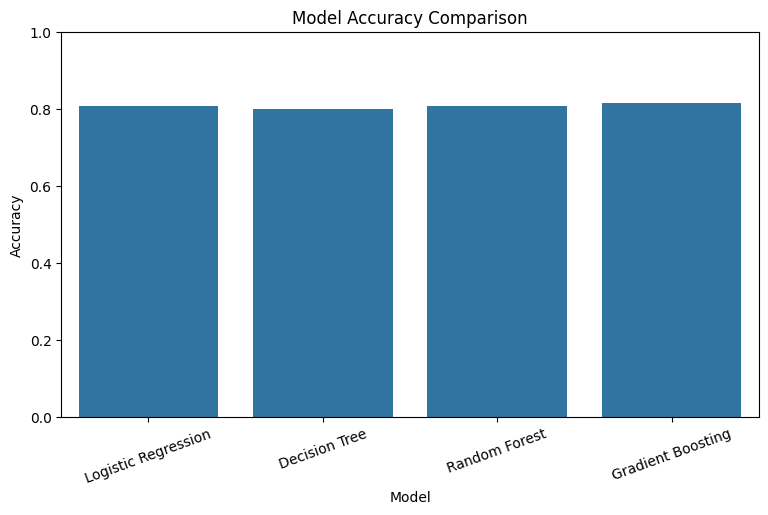

In [66]:
# visualize
plt.figure(figsize=(9,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.ylim(0,1)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=20)

plt.show()

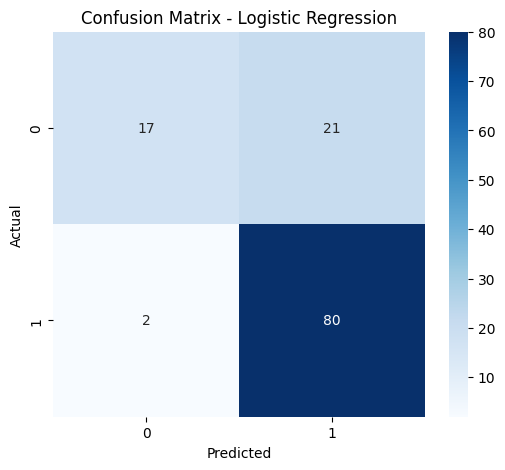

In [67]:
# confusion metrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix - Logistic Regression")

plt.show()



In [68]:
# classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.89      0.45      0.60        38
           1       0.79      0.98      0.87        82

    accuracy                           0.81       120
   macro avg       0.84      0.71      0.74       120
weighted avg       0.82      0.81      0.79       120



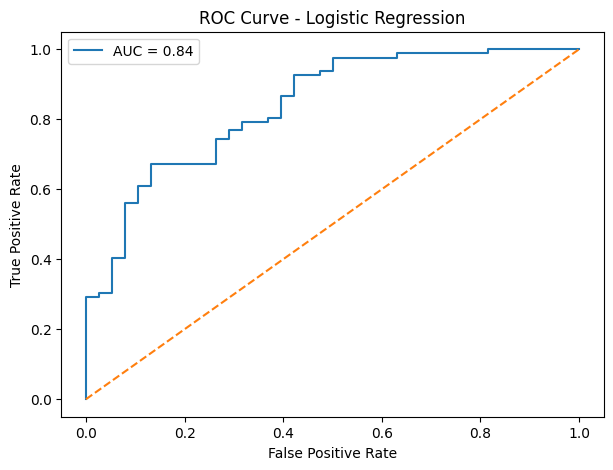

In [71]:
# roc curve
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
y_probability = logistic_model.predict_proba(
    X_test
)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

auc = roc_auc_score(
    y_test,
    y_probability
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.2f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

PREDICT NEW APPLICANT

we can use the trained model to predict whether the new applicant's loan approved or not

In [72]:
new_applicant = pd.DataFrame({
    "Gender": ["Male"],
    "Married": ["Yes"],
    "Dependents": [1],
    "Education": ["Graduate"],
    "Self_Employed": ["No"],
    "ApplicantIncome": [5000],
    "CoapplicantIncome": [2000],
    "LoanAmount": [150],
    "Loan_Amount_Term": [360],
    "Credit_History": [1],
    "Property_Area": ["Urban"]
})

In [73]:
prediction = logistic_model.predict(
    new_applicant
)

probability = logistic_model.predict_proba(
    new_applicant
)[0][1]

In [74]:
if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Not Approved")

print(
    f"Approval Probability: {probability:.2%}"
)

Loan Approved
Approval Probability: 82.12%


Loan Approval prediction is a supervised machine learning classification problem.
The objective is to ppredict whether a loan application will be approved or not
The dataset was cleaned and preprocessed by handling missing values,encoding categorical variables and scaling numerical variables.
EDA was performed using different visualizations to understand the relationship between applicant charecteristics and loan approval.


Gradient Boosting achievedd highest accuracy and approximately 81.67%.
while logistic regression produced consistent perfomance at approximately 80.77%.
Logistic regression can be selected as a reliable final model-loan approval is a binary classification problem because it has 2 outcomes.Logistic regression suitable and interpretable for this type of problem
simpler,faster and easiest to intepret
